# XGBoost Ranker presence-background forecast

Ноутбук реализует supervised-подход через **XGBoost Ranker**.

Важная идея: у нас есть известные проявления / evidence cells, но нет честных negative cells.
Поэтому задача формулируется как **presence-background learning**:

- `positive` = ячейки с evidence;
- `background` = случайно выбранные остальные ячейки;
- модель обучается ранжировать positive выше фона.

В ноутбуке используются геолого-ориентированные признаки:
- proximity и ранговые расстояния;
- буферные признаки;
- node-aware признаки пересечения факторов;
- compact top-zones;
- метрики HitRate top 10/15%.


In [60]:

from pathlib import Path
import math
import random
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union
from shapely.prepared import prep
from pyproj import CRS

from sklearn.preprocessing import RobustScaler
try:
    from xgboost import XGBRanker
except ImportError as e:
    raise ImportError("Для запуска XGBoost Ranker установи пакет: pip install xgboost") from e
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.ndimage import maximum_filter, label

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


# =========================
# CONFIG
# =========================
BASE_DIR = Path(r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз")
SHP_DIR = BASE_DIR / "shp_dbf"
OUT_DIR = BASE_DIR / "xgboost_ranker"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CELL_SIZE = 500

LAYER_MAP = {
    "mask": "svita_new",
    "facies": "fasii",
    "paleo": "gr_dol_vp_poly",
    "struct": "kory",
    "magm": "dayki_buf",
    "tect1": "glub_raz_nw",
    "tect2": "glub_r_nw",
}

EVIDENCE_POINT_LAYER_NAMES = ["result", "геохимическое_опробование"]
USE_EVIDENCE_POLYGONS = False
EVIDENCE_POLYGON_LAYER_NAMES = ["геохимические ореолы", "привнос урана"]

# Масштабы для proximity-признаков.
SCALES = {
    "facies": 1200.0,
    "paleo": 1200.0,
    "struct": 900.0,
    "magm": 900.0,
    "tect1": 1000.0,
    "tect2": 1000.0,
}
BUFFER_DISTANCES = [1000, 1500]

# XGBoost Ranker / presence-background.
RUN_OPTIMIZATION = True
N_TRIALS = 14
TRIAL_ENSEMBLE_SIZE = 8
FINAL_ENSEMBLE_SIZE = 30

# Spatial CV можно выключить, если нужно быстрее.
RUN_SPATIAL_CV = True
N_SPATIAL_SPLITS = 5
SPATIAL_BLOCK_SIZE = 15  # в ячейках сетки

# Top-zone и визуализация.
SMOOTH_PASSES = 3
TOP_ZONE_Q = 0.996
NODE_TOP_ZONE_Q = 0.68
MAX_TOP_ZONE_SHARE = 0.008
LOCAL_MAX_SIZE = 5
MIN_TOP_COMPONENT_CELLS = 4
SHOW_POINTS = True
SEED = 42

random.seed(SEED)
np.random.seed(SEED)



## 1. Вспомогательные функции

Здесь специально используется мягкая загрузка слоёв:
- читаются `*.shp`;
- если CRS не найден, проверяются файлы вида `*_shp.pj4`, `.pj4`, `.qpj`, `.prj`;
- геометрии не чинятся агрессивно через `buffer(0)`, чтобы не “съесть” маску.

In [61]:
def read_sidecar_proj4(path: Path):
    candidates = [
        path.with_name(path.stem + "_shp.pj4"),
        path.with_suffix(".pj4"),
        path.with_suffix(".qpj"),
        path.with_suffix(".prj"),
    ]
    for sidecar in candidates:
        if sidecar.exists():
            txt = sidecar.read_text(encoding="utf-8", errors="ignore").strip()
            if not txt:
                continue
            for line in txt.splitlines():
                line = line.strip()
                if line.lower().startswith("pj4="):
                    return line.split("=", 1)[1].strip()
            return txt
    return None


def repair_geometries(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.copy()
    if "geometry" not in gdf:
        return gdf
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def finite_bounds(gdf: gpd.GeoDataFrame, layer_name: str = "layer"):
    if gdf is None or len(gdf) == 0:
        raise ValueError(f"Слой {layer_name} пуст после базовой очистки геометрий.")
    bounds = np.asarray(gdf.total_bounds, dtype=float)
    if len(bounds) != 4 or not np.all(np.isfinite(bounds)):
        raise ValueError(
            f"Некорректные total_bounds у слоя {layer_name}: {bounds}. "
            "Проверь CRS, исходную геометрию и sidecar-проекцию."
        )
    minx, miny, maxx, maxy = bounds.tolist()
    if maxx <= minx or maxy <= miny:
        raise ValueError(f"У слоя {layer_name} вырожденные границы: {(minx, miny, maxx, maxy)}")
    return minx, miny, maxx, maxy


def load_layer(path: Path) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    gdf = repair_geometries(gdf)
    if gdf.crs is None:
        proj4 = read_sidecar_proj4(path)
        if proj4:
            try:
                gdf = gdf.set_crs(CRS.from_user_input(proj4), allow_override=True)
            except Exception as e:
                print(f"Не удалось прочитать CRS из {path.name}: {e}")
    return gdf


def load_shapefiles(folder: Path):
    layers = {}
    for shp in sorted(folder.glob("*.shp")):
        try:
            layers[shp.stem] = load_layer(shp)
        except Exception as e:
            print(f"Не удалось загрузить {shp.name}: {e}")
    return layers


def to_crs_safe(gdf: gpd.GeoDataFrame, target_crs):
    if target_crs is None:
        return gdf
    if gdf.crs is None:
        return gdf.set_crs(target_crs, allow_override=True)
    if str(gdf.crs) == str(target_crs):
        return gdf
    return gdf.to_crs(target_crs)


def choose_target_crs(mask_gdf: gpd.GeoDataFrame):
    crs = mask_gdf.crs
    if crs is None:
        return None
    try:
        if crs.is_projected:
            return crs
    except Exception:
        pass
    try:
        utm = mask_gdf.estimate_utm_crs()
        if utm is not None:
            return utm
    except Exception:
        pass
    return crs


def harmonize_layers(layers: dict, target_crs):
    out = {}
    for name, gdf in layers.items():
        try:
            cur = to_crs_safe(gdf, target_crs)
            cur = repair_geometries(cur)
            out[name] = cur
        except Exception as e:
            print(f"Не удалось привести CRS слоя {name}: {e}")
            out[name] = gdf
    return out


def discover_point_layers(layers: dict, exclude_names=None):
    exclude_names = set(exclude_names or [])
    candidates = []
    for name, gdf in layers.items():
        if name in exclude_names or len(gdf) == 0:
            continue
        geom_types = set(gdf.geom_type.dropna().unique().tolist())
        if geom_types.issubset({"Point", "MultiPoint"}):
            candidates.append({
                "layer": name,
                "n": int(len(gdf)),
                "geom_types": sorted(list(geom_types)),
            })
    return candidates


def normalize_01(x):
    x = np.asarray(x, dtype=float)
    mn = np.nanmin(x)
    mx = np.nanmax(x)
    if not np.isfinite(mn) or not np.isfinite(mx) or mx <= mn:
        return np.zeros_like(x, dtype=float)
    return (x - mn) / (mx - mn)


def robust_normalize_01(x, q_low=0.02, q_high=0.98):
    x = np.asarray(x, dtype=float)
    lo = np.nanquantile(x, q_low)
    hi = np.nanquantile(x, q_high)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return normalize_01(x)
    y = (x - lo) / (hi - lo)
    return np.clip(y, 0.0, 1.0)


def distance_to_proximity(distances, scale):
    distances = np.asarray(distances, dtype=float)
    return 1.0 / (1.0 + distances / float(scale))


def build_grid(mask_gdf: gpd.GeoDataFrame, cell_size=500):
    minx, miny, maxx, maxy = finite_bounds(mask_gdf, "mask")
    mask_union = unary_union(mask_gdf.geometry)
    prepared_mask = prep(mask_union)

    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(miny, maxy, cell_size)
    rows = len(ys)
    cols = len(xs)
    if rows <= 0 or cols <= 0:
        raise ValueError(f"Некорректный размер сетки: rows={rows}, cols={cols}")

    geoms = []
    rr = []
    cc = []
    for r, y in enumerate(ys):
        for c, x in enumerate(xs):
            cell = box(x, y, x + cell_size, y + cell_size)
            if prepared_mask.intersects(cell):
                geoms.append(cell)
                rr.append(r)
                cc.append(c)

    if len(geoms) == 0:
        raise ValueError("После пересечения с маской сетка пустая. Проверь CRS слоёв и cell_size.")

    grid = gpd.GeoDataFrame({"row": rr, "col": cc}, geometry=geoms, crs=mask_gdf.crs)
    grid["cell_id"] = np.arange(len(grid))
    grid["centroid"] = grid.geometry.centroid
    return grid, (rows, cols), (minx, miny, maxx, maxy)


def compute_distance_feature(grid, source_gdf, scale):
    if source_gdf is None or len(source_gdf) == 0:
        dist = np.full(len(grid), np.nan, dtype=float)
        prox = np.zeros(len(grid), dtype=float)
        return dist, prox
    union_geom = unary_union(source_gdf.geometry)
    dist = grid["centroid"].distance(union_geom).to_numpy(dtype=float)
    prox = distance_to_proximity(dist, scale)
    return dist, prox


def compute_intersection_proximity(grid, gdf_a, gdf_b, scale=1200.0):
    """
    Признак близости к реальному геометрическому узлу пересечения двух слоёв.
    Работает для линий, полигонов и их границ. Если пересечения нет, возвращает нули.
    """
    try:
        if gdf_a is None or gdf_b is None or len(gdf_a) == 0 or len(gdf_b) == 0:
            return np.full(len(grid), np.nan, dtype=float), np.zeros(len(grid), dtype=float)
        geom_a = unary_union(gdf_a.geometry)
        geom_b = unary_union(gdf_b.geometry)
        inter = geom_a.intersection(geom_b)
        if inter is None or inter.is_empty:
            # Для полигональных слоёв иногда полезнее пересечение границ.
            try:
                inter = geom_a.boundary.intersection(geom_b.boundary)
            except Exception:
                pass
        if inter is None or inter.is_empty:
            return np.full(len(grid), np.nan, dtype=float), np.zeros(len(grid), dtype=float)
        dist = grid["centroid"].distance(inter).to_numpy(dtype=float)
        prox = distance_to_proximity(dist, scale)
        return dist, prox
    except Exception as e:
        print(f"Не удалось посчитать intersection proximity: {e}")
        return np.full(len(grid), np.nan, dtype=float), np.zeros(len(grid), dtype=float)


def smooth_on_regular_grid(arr: np.ndarray, valid_mask: np.ndarray, passes=2):
    work = arr.astype(float).copy()
    valid = valid_mask.astype(bool)

    for _ in range(int(passes)):
        num = np.zeros_like(work, dtype=float)
        den = np.zeros_like(work, dtype=float)
        finite_work = np.where(np.isfinite(work) & valid, work, 0.0)
        finite_mask = (np.isfinite(work) & valid).astype(float)

        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                shifted = np.roll(np.roll(finite_work, dr, axis=0), dc, axis=1)
                shifted_valid = np.roll(np.roll(finite_mask, dr, axis=0), dc, axis=1)

                if dr > 0:
                    shifted[:dr, :] = 0.0
                    shifted_valid[:dr, :] = 0.0
                elif dr < 0:
                    shifted[dr:, :] = 0.0
                    shifted_valid[dr:, :] = 0.0

                if dc > 0:
                    shifted[:, :dc] = 0.0
                    shifted_valid[:, :dc] = 0.0
                elif dc < 0:
                    shifted[:, dc:] = 0.0
                    shifted_valid[:, dc:] = 0.0

                num += shifted
                den += shifted_valid

        with np.errstate(divide="ignore", invalid="ignore"):
            smoothed = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
        work = np.where(valid, smoothed, np.nan)

    return work


def connected_component_filter_array(binary_arr, min_cells=2):
    binary_arr = np.asarray(binary_arr).astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)
    labeled, ncomp = label(binary_arr, structure=structure)
    keep = np.zeros_like(binary_arr, dtype=np.uint8)
    for cid in range(1, ncomp + 1):
        comp = (labeled == cid)
        if comp.sum() >= min_cells:
            keep[comp] = 1
    return keep.astype(np.uint8)





## 2. Загрузка слоёв и построение сетки

In [62]:
layers_raw = load_shapefiles(SHP_DIR)
print("Слои:", sorted(layers_raw.keys()))

for logical_name, layer_name in LAYER_MAP.items():
    if layer_name not in layers_raw:
        raise FileNotFoundError(f"Не найден обязательный слой {logical_name}: {layer_name}")

mask_name = LAYER_MAP["mask"]
target_crs = choose_target_crs(layers_raw[mask_name])
layers = harmonize_layers(layers_raw, target_crs)

print("Используемые слои:", LAYER_MAP)
point_candidates = discover_point_layers(layers, exclude_names=set(LAYER_MAP.values()))
print("Точечные слои-кандидаты:", point_candidates)

grid, GRID_SHAPE, GRID_BOUNDS = build_grid(layers[LAYER_MAP["mask"]], CELL_SIZE)
rows, cols = GRID_SHAPE
minx, miny, maxx, maxy = GRID_BOUNDS

print("Ячеек в сетке:", len(grid))
print("Размер сетки (rows, cols):", GRID_SHAPE)
print("Границы:", GRID_BOUNDS)




Слои: ['dayki_buf', 'fasii', 'glub_r_nw', 'glub_raz_nw', 'gr_dol_vp_poly', 'kory', 'result', 'svita_new', 'геохимические ореолы', 'геохимическое_опробование', 'привнос урана']
Используемые слои: {'mask': 'svita_new', 'facies': 'fasii', 'paleo': 'gr_dol_vp_poly', 'struct': 'kory', 'magm': 'dayki_buf', 'tect1': 'glub_raz_nw', 'tect2': 'glub_r_nw'}
Точечные слои-кандидаты: [{'layer': 'result', 'n': 1332, 'geom_types': ['Point']}, {'layer': 'геохимическое_опробование', 'n': 76, 'geom_types': ['Point']}]
Ячеек в сетке: 15684
Размер сетки (rows, cols): (154, 145)
Границы: (536943.9873052016, 7843798.723451863, 609121.2875210745, 7920537.4178847205)


## 3. Расчёт признаков факторов

XGBoost Ranker получает геолого-ориентированный набор признаков по ячейкам:
- близость к факторам;
- ранговые расстояния;
- бинарные буферы `1000/1500 м`;
- несколько простых логических комбинаций.

Дальше модель с учителем учится отличать evidence cells от фоновой выборки.


Базовые distance/proximity-признаки

In [63]:
for key in ["facies", "paleo", "struct", "magm", "tect1", "tect2"]:
    layer_name = LAYER_MAP[key]
    dist, prox = compute_distance_feature(grid, layers[layer_name], SCALES[key])
    grid[f"dist_{key}"] = dist
    grid[f"prox_{key}"] = prox

# Агрегированная тектоника: один общий tect_any вместо двух сильно дублирующих направлений.
grid["dist_tect_any"] = np.minimum(grid["dist_tect1"].to_numpy(float), grid["dist_tect2"].to_numpy(float))
grid["prox_tect_any"] = distance_to_proximity(grid["dist_tect_any"], scale=1000.0)

# Ранговое кодирование расстояний: 1 = ближе, 0 = дальше.
for key in ["facies", "paleo", "struct", "magm", "tect1", "tect2", "tect_any"]:
    s = pd.Series(grid[f"dist_{key}"].astype(float))
    grid[f"rank_near_{key}"] = 1.0 - s.rank(method="average", pct=True).to_numpy()
    grid[f"rank_near_{key}"] = grid[f"rank_near_{key}"].fillna(0.0)

# =========================
# NODE-AWARE GEOLOGICAL FEATURE SET
# =========================
# Цель блока — не просто подсветить разломные линии, а описать структурные узлы:
# 1) сколько разнородных факторов совпало в радиусе;
# 2) сколько парных/тройных сочетаний факторов активно;
# 3) близость к реальным геометрическим пересечениям слоёв.

NON_TECT_KEYS = ["facies", "paleo", "struct", "magm"]
ALL_KEYS = ["facies", "paleo", "struct", "magm", "tect1", "tect2"]

# Бинарные буферы считаем для всех факторов, но в признаки индивидуальные tect1/tect2 не подаём.
for key in ALL_KEYS:
    for b in BUFFER_DISTANCES:
        grid[f"buf_{key}_{b}"] = (grid[f"dist_{key}"] <= b).astype(int)

PAIR_DEFS = []
TRIPLE_DEFS = []

for b in BUFFER_DISTANCES:
    grid[f"tect_any_{b}"] = ((grid[f"buf_tect1_{b}"] == 1) | (grid[f"buf_tect2_{b}"] == 1)).astype(int)
    grid[f"tect_cross_{b}"] = ((grid[f"buf_tect1_{b}"] == 1) & (grid[f"buf_tect2_{b}"] == 1)).astype(int)

    # Активные классы факторов считаем по 5 классам: facies, paleo, struct, magm, tect_any.
    active_cols = [f"buf_{key}_{b}" for key in NON_TECT_KEYS] + [f"tect_any_{b}"]
    grid[f"active_factor_count_{b}"] = grid[active_cols].sum(axis=1)
    grid[f"multi_factor_3plus_{b}"] = (grid[f"active_factor_count_{b}"] >= 3).astype(int)
    grid[f"multi_factor_4plus_{b}"] = (grid[f"active_factor_count_{b}"] >= 4).astype(int)

    # Парные узлы: не все возможные пары, а геологически читаемые сочетания.
    pair_exprs = {
        f"node_tect_magm_{b}":      (grid[f"tect_any_{b}"] & grid[f"buf_magm_{b}"]),
        f"node_tect_struct_{b}":    (grid[f"tect_any_{b}"] & grid[f"buf_struct_{b}"]),
        f"node_tect_paleo_{b}":     (grid[f"tect_any_{b}"] & grid[f"buf_paleo_{b}"]),
        f"node_tect_facies_{b}":    (grid[f"tect_any_{b}"] & grid[f"buf_facies_{b}"]),
        f"node_struct_paleo_{b}":   (grid[f"buf_struct_{b}"] & grid[f"buf_paleo_{b}"]),
        f"node_magm_struct_{b}":    (grid[f"buf_magm_{b}"] & grid[f"buf_struct_{b}"]),
        f"node_magm_paleo_{b}":     (grid[f"buf_magm_{b}"] & grid[f"buf_paleo_{b}"]),
        f"node_facies_paleo_{b}":   (grid[f"buf_facies_{b}"] & grid[f"buf_paleo_{b}"]),
    }
    for col, val in pair_exprs.items():
        grid[col] = val.astype(int)
    pair_cols = list(pair_exprs.keys())
    PAIR_DEFS.extend(pair_cols)

    # Тройные узлы: именно они чаще всего похожи на локальные перспективные центры.
    triple_exprs = {
        f"triple_tect_magm_struct_{b}":   (grid[f"tect_any_{b}"] & grid[f"buf_magm_{b}"] & grid[f"buf_struct_{b}"]),
        f"triple_tect_paleo_struct_{b}":  (grid[f"tect_any_{b}"] & grid[f"buf_paleo_{b}"] & grid[f"buf_struct_{b}"]),
        f"triple_tect_paleo_facies_{b}":  (grid[f"tect_any_{b}"] & grid[f"buf_paleo_{b}"] & grid[f"buf_facies_{b}"]),
        f"triple_tect_magm_paleo_{b}":    (grid[f"tect_any_{b}"] & grid[f"buf_magm_{b}"] & grid[f"buf_paleo_{b}"]),
        f"triple_facies_paleo_struct_{b}":(grid[f"buf_facies_{b}"] & grid[f"buf_paleo_{b}"] & grid[f"buf_struct_{b}"]),
    }
    for col, val in triple_exprs.items():
        grid[col] = val.astype(int)
    triple_cols = list(triple_exprs.keys())
    TRIPLE_DEFS.extend(triple_cols)

    grid[f"node_pair_count_{b}"] = grid[pair_cols].sum(axis=1)
    grid[f"node_triple_count_{b}"] = grid[triple_cols].sum(axis=1)
    grid[f"node_complexity_{b}"] = (
        0.35 * normalize_01(grid[f"active_factor_count_{b}"]) +
        0.35 * normalize_01(grid[f"node_pair_count_{b}"]) +
        0.30 * normalize_01(grid[f"node_triple_count_{b}"])
    )

# Близость к реальным геометрическим пересечениям слоёв.
INTERSECTION_PAIRS = [
    ("tect1", "tect2", "tect1_tect2"),
    ("tect1", "magm", "tect1_magm"),
    ("tect2", "magm", "tect2_magm"),
    ("tect1", "paleo", "tect1_paleo"),
    ("tect2", "paleo", "tect2_paleo"),
    ("tect1", "struct", "tect1_struct"),
    ("tect2", "struct", "tect2_struct"),
    ("magm", "struct", "magm_struct"),
    ("struct", "paleo", "struct_paleo"),
]
nodeprox_cols = []
for a, b, name in INTERSECTION_PAIRS:
    dist, prox = compute_intersection_proximity(grid, layers[LAYER_MAP[a]], layers[LAYER_MAP[b]], scale=1200.0)
    grid[f"dist_node_{name}"] = dist
    grid[f"prox_node_{name}"] = prox
    nodeprox_cols.append(f"prox_node_{name}")

# Единый диагностический индекс узловости. Он помогает контролировать выделение top-zone.
node_strength_components = []
for b in BUFFER_DISTANCES:
    node_strength_components += [
        f"node_complexity_{b}",
        f"node_pair_count_{b}",
        f"node_triple_count_{b}",
        f"tect_cross_{b}",
    ]
node_strength_components += nodeprox_cols
node_strength_matrix = grid[node_strength_components].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy()
node_strength_scaled = np.column_stack([robust_normalize_01(node_strength_matrix[:, i]) for i in range(node_strength_matrix.shape[1])])
grid["node_strength_raw"] = node_strength_scaled.mean(axis=1)
grid["node_strength"] = robust_normalize_01(grid["node_strength_raw"], 0.02, 0.98)

FEATURE_COLS = []

# Плавный фон: non-tect факторы + агрегированная тектоника.
FEATURE_COLS += [f"prox_{k}" for k in NON_TECT_KEYS]
FEATURE_COLS += ["prox_tect_any"]
FEATURE_COLS += [f"rank_near_{k}" for k in NON_TECT_KEYS]
FEATURE_COLS += ["rank_near_tect_any"]

# Буферы: индивидуально non-tect, тектоника только как aggregate.
for b in BUFFER_DISTANCES:
    FEATURE_COLS += [f"buf_{k}_{b}" for k in NON_TECT_KEYS]
    FEATURE_COLS += [
        f"tect_any_{b}",
        f"tect_cross_{b}",
        f"active_factor_count_{b}",
        f"multi_factor_3plus_{b}",
        f"multi_factor_4plus_{b}",
        f"node_pair_count_{b}",
        f"node_triple_count_{b}",
        f"node_complexity_{b}",
    ]

# Узловые пары/тройки и реальные геометрические intersection proximity.
FEATURE_COLS += PAIR_DEFS
FEATURE_COLS += TRIPLE_DEFS
FEATURE_COLS += nodeprox_cols
FEATURE_COLS += ["node_strength"]

# Удаляем возможные дубли.
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))

X_raw = grid[FEATURE_COLS].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy()
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)
# После RobustScaler приведём каждый столбец к 0..1, чтобы отдельные выбросы не доминировали в модели.
X_base = np.column_stack([robust_normalize_01(X_scaled[:, i]) for i in range(X_scaled.shape[1])]).astype(np.float32)

print("Количество признаков для XGBoost Ranker:", len(FEATURE_COLS))
print("Размер X:", X_base.shape)
print("Средняя node_strength:", float(grid["node_strength"].mean()))




Количество признаков для XGBoost Ranker: 70
Размер X: (15684, 70)
Средняя node_strength: 0.3283576021568984


## 4. Evidence cells: известные проявления и геохимические признаки

Эти данные используются как positive-класс. Остальные ячейки рассматриваются как фоновая выборка, а не как доказанные отрицательные примеры.

In [64]:
def collect_evidence_points(layers, point_names, candidates, target_crs):
    if point_names is None:
        names = [x["layer"] for x in candidates]
    else:
        names = [n for n in point_names if n in layers]

    point_gdfs = []
    for name in names:
        gdf = layers[name].copy()
        if len(gdf) == 0:
            continue
        try:
            gdf = to_crs_safe(gdf, target_crs)
        except Exception:
            pass
        gdf = repair_geometries(gdf)
        gdf["source_layer"] = name
        point_gdfs.append(gdf[["source_layer", "geometry"]].copy())

    if not point_gdfs:
        return gpd.GeoDataFrame({"source_layer": []}, geometry=[], crs=target_crs), []

    pts = pd.concat(point_gdfs, ignore_index=True)
    pts = gpd.GeoDataFrame(pts, geometry="geometry", crs=target_crs)
    return pts, names


def mark_evidence_cells(grid, layers, point_names, polygon_names, candidates, target_crs):
    grid_e = grid[["cell_id", "geometry"]].copy()
    evidence_cell_ids = set()

    points_raw, used_points = collect_evidence_points(layers, point_names, candidates, target_crs)
    points_plot = gpd.GeoDataFrame({"source_layer": []}, geometry=[], crs=target_crs)

    if len(points_raw) > 0:
        # intersects безопаснее, чем within, потому что точки на границе ячеек тоже попадут.
        sj = gpd.sjoin(points_raw, grid_e, how="inner", predicate="intersects")
        if len(sj) > 0:
            evidence_cell_ids.update(sj["cell_id"].astype(int).tolist())
            points_plot = sj.drop(columns=["index_right"], errors="ignore").copy()

    used_polygons = []
    if USE_EVIDENCE_POLYGONS:
        for name in polygon_names:
            if name not in layers:
                continue
            gdf = layers[name].copy()
            if len(gdf) == 0:
                continue
            geom_types = set(gdf.geom_type.dropna().unique().tolist())
            if geom_types.issubset({"Point", "MultiPoint"}):
                continue
            try:
                gdf = to_crs_safe(gdf, target_crs)
            except Exception:
                pass
            gdf = repair_geometries(gdf)
            if len(gdf) == 0:
                continue
            used_polygons.append(name)
            sj_poly = gpd.sjoin(grid_e, gdf[["geometry"]], how="inner", predicate="intersects")
            if len(sj_poly) > 0:
                evidence_cell_ids.update(sj_poly["cell_id"].astype(int).tolist())

    evidence = np.zeros(len(grid), dtype=np.uint8)
    if evidence_cell_ids:
        evidence[list(evidence_cell_ids)] = 1
    return evidence, points_raw, points_plot, used_points, used_polygons


grid["evidence_cell"], evidence_points_raw, evidence_points_plot, used_point_layers, used_polygon_layers = mark_evidence_cells(
    grid=grid,
    layers=layers,
    point_names=EVIDENCE_POINT_LAYER_NAMES,
    polygon_names=EVIDENCE_POLYGON_LAYER_NAMES,
    candidates=point_candidates,
    target_crs=target_crs,
)

print("Используем point-слои evidence:", used_point_layers)
print("Используем polygon-слои evidence:", used_polygon_layers)
print("Количество evidence points raw:", len(evidence_points_raw))
print("Количество evidence points внутри сетки:", len(evidence_points_plot))
print("Количество evidence cells:", int(grid["evidence_cell"].sum()))
print("Доля evidence cells:", float(grid["evidence_cell"].mean()))







Используем point-слои evidence: ['result', 'геохимическое_опробование']
Используем polygon-слои evidence: []
Количество evidence points raw: 1408
Количество evidence points внутри сетки: 71
Количество evidence cells: 68
Доля evidence cells: 0.004335628666156593


## 5. XGBoost Ranker presence-background

Здесь используется не обычная схема `positive` против `все остальные как negative`,
а presence-background:
- positive = evidence cells;
- background = случайная подвыборка остальных ячеек.

Для устойчивости обучается ансамбль XGBoost Ranker на разных background-подвыборках,
после чего прогнозы усредняются.

In [65]:
def make_xgboost_ranker_model(params, seed=SEED):
    """
    XGBoost Ranker для presence-background обучения.
    Модель учится ранжировать evidence cells выше фоновых ячеек.
    """
    return XGBRanker(
        objective="rank:pairwise",
        n_estimators=int(params.get("N_ESTIMATORS", 160)),
        learning_rate=float(params.get("LEARNING_RATE", 0.04)),
        max_depth=int(params.get("MAX_DEPTH", 2)),
        min_child_weight=float(params.get("MIN_CHILD_WEIGHT", 1.0)),
        subsample=float(params.get("SUBSAMPLE", 0.85)),
        colsample_bytree=float(params.get("COLSAMPLE_BYTREE", 0.85)),
        reg_lambda=float(params.get("REG_LAMBDA", 1.0)),
        reg_alpha=float(params.get("REG_ALPHA", 0.0)),
        tree_method="hist",
        random_state=int(seed),
        n_jobs=1,
    )


def train_presence_background_ensemble(X_input, y_evidence, params, ensemble_size=30, seed=SEED, train_mask=None):
    rng = np.random.default_rng(seed)
    y_evidence = np.asarray(y_evidence).astype(int)

    if train_mask is None:
        train_mask = np.ones(len(y_evidence), dtype=bool)
    else:
        train_mask = np.asarray(train_mask).astype(bool)

    pos_idx = np.where((y_evidence == 1) & train_mask)[0]
    bg_pool = np.where((y_evidence == 0) & train_mask)[0]

    if len(pos_idx) < 2:
        raise ValueError("Слишком мало positive cells для XGBoost Ranker.")
    if len(bg_pool) < 5:
        raise ValueError("Слишком мало background cells для XGBoost Ranker.")

    bg_ratio = int(params.get("BACKGROUND_RATIO", 6))
    n_bg = min(len(bg_pool), max(len(pos_idx) * bg_ratio, len(pos_idx)))

    preds = np.zeros(len(y_evidence), dtype=float)
    importance_rows = []

    for m in range(int(ensemble_size)):
        bg_idx = rng.choice(bg_pool, size=n_bg, replace=False)
        train_idx = np.concatenate([pos_idx, bg_idx])
        y_train = np.concatenate([np.ones(len(pos_idx), dtype=float), np.zeros(len(bg_idx), dtype=float)])

        # Для ranker важны пары внутри одной группы: evidence должны получить ранг выше background.
        perm = rng.permutation(len(train_idx))
        train_idx = train_idx[perm]
        y_train = y_train[perm]
        group = [len(train_idx)]

        model = make_xgboost_ranker_model(params, seed=seed + 100 + m)
        model.fit(X_input[train_idx], y_train, group=group, verbose=False)
        preds += model.predict(X_input)

        try:
            importance_rows.append(model.feature_importances_.ravel())
        except Exception:
            pass

    preds /= float(ensemble_size)
    preds = robust_normalize_01(preds, 0.02, 0.98)
    importance_mean = np.mean(np.vstack(importance_rows), axis=0) if importance_rows else np.zeros(X_input.shape[1])
    return preds, importance_mean


def array_from_grid_values(values):
    arr = np.full((rows, cols), np.nan, dtype=float)
    valid = np.zeros((rows, cols), dtype=bool)
    for val, r, c in zip(values, grid["row"].to_numpy(int), grid["col"].to_numpy(int)):
        arr[int(r), int(c)] = float(val)
        valid[int(r), int(c)] = True
    return arr, valid


def values_from_array(arr):
    return np.array([arr[int(r), int(c)] for r, c in zip(grid["row"], grid["col"])], dtype=float)


def build_top_zone(prospectivity_arr, node_strength_arr, valid_mask, params):
    top_q = float(params.get("TOP_ZONE_Q", TOP_ZONE_Q))
    node_q = float(params.get("NODE_TOP_ZONE_Q", NODE_TOP_ZONE_Q))
    max_share = float(params.get("MAX_TOP_ZONE_SHARE", MAX_TOP_ZONE_SHARE))
    local_size = int(params.get("LOCAL_MAX_SIZE", LOCAL_MAX_SIZE))
    min_cells = int(params.get("MIN_TOP_COMPONENT_CELLS", MIN_TOP_COMPONENT_CELLS))

    p_thr = float(np.nanquantile(prospectivity_arr[valid_mask], top_q))
    n_thr = float(np.nanquantile(node_strength_arr[valid_mask], node_q))
    local_max = maximum_filter(np.nan_to_num(prospectivity_arr, nan=-999.0), size=local_size)

    candidate = (
        (prospectivity_arr >= p_thr) &
        (prospectivity_arr >= local_max - 1e-9) &
        (node_strength_arr >= n_thr) &
        valid_mask
    )
    top = connected_component_filter_array(candidate.astype(np.uint8), min_cells=min_cells)

    # Если local maxima слишком строги и зона пустая, ослабляем только local maxima.
    if int(top.sum()) == 0:
        candidate = (prospectivity_arr >= p_thr) & (node_strength_arr >= n_thr) & valid_mask
        top = connected_component_filter_array(candidate.astype(np.uint8), min_cells=min_cells)

    # Жёстко ограничиваем площадь top-zone, чтобы не залить половину карты.
    max_cells = max(1, int(np.floor(max_share * int(valid_mask.sum()))))
    if int(top.sum()) > max_cells:
        coords = np.argwhere(top.astype(bool))
        score = np.array([
            0.78 * float(prospectivity_arr[r, c]) + 0.22 * float(node_strength_arr[r, c])
            for r, c in coords
        ])
        keep = coords[np.argsort(-score)[:max_cells]]
        limited = np.zeros_like(top, dtype=np.uint8)
        for r, c in keep:
            limited[int(r), int(c)] = 1
        top = connected_component_filter_array(limited, min_cells=max(1, min_cells - 1))

    return top.astype(np.uint8), p_thr, n_thr


def hitrate_at_quantile(score_values, evidence_values, q):
    score_values = np.asarray(score_values, dtype=float)
    evidence_values = np.asarray(evidence_values).astype(bool)
    thr = float(np.nanquantile(score_values, q))
    top = score_values >= thr
    n_ev = int(evidence_values.sum())
    if n_ev == 0:
        return 0.0, 0, thr
    return float((top & evidence_values).sum() / n_ev), int((top & evidence_values).sum()), thr


def evaluate_prediction(score_values, top_zone_arr, params):
    evidence = grid["evidence_cell"].to_numpy(int).astype(bool)
    h10, ev10, thr10 = hitrate_at_quantile(score_values, evidence, 0.90)
    h15, ev15, thr15 = hitrate_at_quantile(score_values, evidence, 0.85)
    top_values = values_from_array(top_zone_arr).astype(bool)
    top_share = float(top_values.mean())
    top_ev = int((top_values & evidence).sum())

    if top_values.any():
        node_top = float(grid.loc[top_values, "node_strength"].mean())
        active_top = float(0.5 * grid.loc[top_values, "active_factor_count_1000"].mean() + 0.5 * grid.loc[top_values, "active_factor_count_1500"].mean())
    else:
        node_top = 0.0
        active_top = 0.0

    comp = component_stats(top_zone_arr) if "component_stats" in globals() else {"component_count": 0}
    ncomp = int(comp.get("component_count", 0))
    area_bonus = float(np.clip(1.0 - abs(top_share - params.get("MAX_TOP_ZONE_SHARE", MAX_TOP_ZONE_SHARE)) / max(1e-9, params.get("MAX_TOP_ZONE_SHARE", MAX_TOP_ZONE_SHARE)), 0, 1))
    component_bonus = float(np.clip(1.0 - abs(ncomp - 4) / 6.0, 0, 1)) if ncomp > 0 else 0.0

    # В objective не только hitrate: иначе модель будет расширять зоны вокруг точек.
    objective = (
        0.34 * h10 +
        0.18 * h15 +
        0.18 * node_top +
        0.10 * min(active_top / 5.0, 1.0) +
        0.12 * area_bonus +
        0.08 * component_bonus
    )
    return {
        "objective": float(objective),
        "hitrate_top10": float(h10),
        "hitrate_top15": float(h15),
        "top_zone_share": float(top_share),
        "top_zone_cells": int(top_values.sum()),
        "top_zone_evidence_cells": int(top_ev),
        "node_top_mean": float(node_top),
        "active_top_mean": float(active_top),
        "top_zone_components": int(ncomp),
    }


def component_stats(binary_arr):
    arr = np.asarray(binary_arr).astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)
    labeled, ncomp = label(arr, structure=structure)
    sizes = [int((labeled == i).sum()) for i in range(1, ncomp + 1)]
    return {"component_count": int(ncomp), "component_sizes": sizes, "largest_component": int(max(sizes) if sizes else 0)}


def run_trial(params, ensemble_size, seed):
    y = grid["evidence_cell"].to_numpy(int)
    score, importance = train_presence_background_ensemble(X_RANKER, y, params, ensemble_size=ensemble_size, seed=seed)
    arr, valid_mask = array_from_grid_values(score)
    arr = smooth_on_regular_grid(arr, valid_mask, passes=int(params.get("SMOOTH_PASSES", SMOOTH_PASSES)))
    arr = robust_normalize_01(arr, 0.02, 0.98)
    node_arr, _ = array_from_grid_values(grid["node_strength"].to_numpy(float))
    node_arr = smooth_on_regular_grid(node_arr, valid_mask, passes=1)
    node_arr = robust_normalize_01(node_arr, 0.02, 0.98)
    top_arr, p_thr, n_thr = build_top_zone(arr, node_arr, valid_mask, params)
    score_values = values_from_array(arr)
    metrics = evaluate_prediction(score_values, top_arr, params)
    metrics.update({"prospectivity_threshold": float(p_thr), "node_threshold": float(n_thr)})
    return score_values, arr, node_arr, top_arr, importance, metrics


# Подготовка матрицы для XGBoost Ranker.
# X_base уже рассчитан выше по геолого-ориентированным признакам.
# Для XGBoost Ranker используем нормализованные признаки; модель учится ранжировать evidence cells выше фоновых ячеек.
X_RANKER = X_base.copy()

print("Матрица признаков XGBoost Ranker:", X_RANKER.shape)
print("Positive/evidence cells:", int(grid["evidence_cell"].sum()))


def sample_params(rng, trial_idx):
    if trial_idx == 0:
        return {
            "N_ESTIMATORS": 160,
            "LEARNING_RATE": 0.04,
            "MAX_DEPTH": 2,
            "MIN_CHILD_WEIGHT": 1.0,
            "SUBSAMPLE": 0.85,
            "COLSAMPLE_BYTREE": 0.85,
            "REG_LAMBDA": 1.0,
            "REG_ALPHA": 0.0,
            "BACKGROUND_RATIO": 8,
            "SMOOTH_PASSES": 3,
            "TOP_ZONE_Q": 0.996,
            "NODE_TOP_ZONE_Q": 0.68,
            "MAX_TOP_ZONE_SHARE": 0.008,
            "LOCAL_MAX_SIZE": 5,
            "MIN_TOP_COMPONENT_CELLS": 4,
        }
    return {
        "N_ESTIMATORS": int(rng.choice([80, 120, 160, 220, 300])),
        "LEARNING_RATE": float(rng.choice([0.02, 0.03, 0.04, 0.06, 0.08])),
        "MAX_DEPTH": int(rng.choice([1, 2, 3, 4])),
        "MIN_CHILD_WEIGHT": float(rng.choice([0.5, 1.0, 2.0, 4.0])),
        "SUBSAMPLE": float(rng.choice([0.70, 0.85, 1.00])),
        "COLSAMPLE_BYTREE": float(rng.choice([0.70, 0.85, 1.00])),
        "REG_LAMBDA": float(rng.choice([0.5, 1.0, 2.0, 5.0])),
        "REG_ALPHA": float(rng.choice([0.0, 0.05, 0.10, 0.25])),
        "BACKGROUND_RATIO": int(rng.choice([3, 5, 6, 8, 10])),
        "SMOOTH_PASSES": int(rng.choice([2, 3, 4])),
        "TOP_ZONE_Q": float(rng.choice([0.994, 0.995, 0.996, 0.997])),
        "NODE_TOP_ZONE_Q": float(rng.choice([0.60, 0.65, 0.68, 0.72])),
        "MAX_TOP_ZONE_SHARE": float(rng.choice([0.006, 0.008, 0.010, 0.012])),
        "LOCAL_MAX_SIZE": int(rng.choice([5, 7])),
        "MIN_TOP_COMPONENT_CELLS": int(rng.choice([3, 4, 5])),
    }

rng = np.random.default_rng(SEED + 100)
trial_rows = []
if RUN_OPTIMIZATION:
    print(f"Запуск Random Search для XGBoost Ranker: N_TRIALS={N_TRIALS}")
    for trial_idx in range(int(N_TRIALS)):
        params = sample_params(rng, trial_idx)
        score_values, arr, node_arr, top_arr, importance, metrics = run_trial(
            params,
            ensemble_size=TRIAL_ENSEMBLE_SIZE,
            seed=SEED + 1000 + trial_idx,
        )
        row = {"trial": trial_idx, **metrics, **params}
        trial_rows.append(row)
        print(
            f"Trial {trial_idx+1:02d}/{N_TRIALS} | objective={metrics['objective']:.4f} | "
            f"h10={metrics['hitrate_top10']:.3f} | h15={metrics['hitrate_top15']:.3f} | "
            f"top_share={metrics['top_zone_share']:.4f} | n_estimators={params['N_ESTIMATORS']} | learning_rate={params['LEARNING_RATE']} | depth={params['MAX_DEPTH']}"
        )
else:
    params = sample_params(rng, 0)
    score_values, arr, node_arr, top_arr, importance, metrics = run_trial(params, ensemble_size=TRIAL_ENSEMBLE_SIZE, seed=SEED)
    trial_rows.append({"trial": 0, **metrics, **params})

results_df = pd.DataFrame(trial_rows).sort_values("objective", ascending=False)
best_params = {k: results_df.iloc[0][k] for k in sample_params(np.random.default_rng(1), 0).keys()}
print("\nЛучшие параметры XGBoost Ranker:")
best_params = {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) for k, v in best_params.items()}
for int_key in ["N_ESTIMATORS", "MAX_DEPTH", "BACKGROUND_RATIO", "SMOOTH_PASSES", "LOCAL_MAX_SIZE", "MIN_TOP_COMPONENT_CELLS"]:
    if int_key in best_params:
        best_params[int_key] = int(best_params[int_key])
print(best_params)

# Финальное обучение с лучшими параметрами.
print("\nФинальное обучение XGBoost Ranker presence-background ensemble...")
score_values, prospectivity_arr, node_strength_arr, top_zone_arr, importance_mean, final_metrics = run_trial(
    best_params,
    ensemble_size=FINAL_ENSEMBLE_SIZE,
    seed=SEED + 555,
)

grid["prospectivity"] = score_values
grid["top_zone"] = values_from_array(top_zone_arr).astype(int)

print("Evidence cells:", int(grid["evidence_cell"].sum()))
print("Top-zone cells:", int(grid["top_zone"].sum()))
print("Top-zone share:", float(grid["top_zone"].mean()))
print("HitRate top 10%:", final_metrics["hitrate_top10"])
print("HitRate top 15%:", final_metrics["hitrate_top15"])

# Пространственная presence-background проверка.
if RUN_SPATIAL_CV:
    print("\nSpatial blocked CV для presence-background XGBoost Ranker...")
    groups = (grid["row"].to_numpy(int) // SPATIAL_BLOCK_SIZE) * 1000 + (grid["col"].to_numpy(int) // SPATIAL_BLOCK_SIZE)
    y = grid["evidence_cell"].to_numpy(int)
    cv = GroupKFold(n_splits=int(N_SPATIAL_SPLITS))
    aucs, aps = [], []
    for fold, (tr, te) in enumerate(cv.split(X_RANKER, y, groups), start=1):
        train_mask = np.zeros(len(y), dtype=bool)
        train_mask[tr] = True
        try:
            pred, _ = train_presence_background_ensemble(
                X_RANKER, y, best_params,
                ensemble_size=max(8, TRIAL_ENSEMBLE_SIZE),
                seed=SEED + 2000 + fold,
                train_mask=train_mask,
            )
            if len(np.unique(y[te])) >= 2:
                auc = roc_auc_score(y[te], pred[te])
                ap = average_precision_score(y[te], pred[te])
                aucs.append(float(auc))
                aps.append(float(ap))
                print(f"Fold {fold}: ROC-AUC={auc:.3f}, AP={ap:.3f}")
            else:
                print(f"Fold {fold}: пропуск, в test только один класс")
        except Exception as e:
            print(f"Fold {fold}: ошибка CV: {e}")
    if aucs:
        print("CV mean ROC-AUC:", float(np.mean(aucs)))
        print("CV mean AP:", float(np.mean(aps)))

# Важность признаков модели.
importance_df = pd.DataFrame({"feature": FEATURE_COLS, "importance_mean": importance_mean})
importance_df = importance_df.sort_values("importance_mean", ascending=False)
print("\nТоп-15 признаков по важности:")
print(importance_df.head(15).to_string(index=False))



Матрица признаков XGBoost Ranker: (15684, 70)
Positive/evidence cells: 68
Запуск Random Search для XGBoost Ranker: N_TRIALS=14
Trial 01/14 | objective=0.4668 | h10=0.471 | h15=0.618 | top_share=0.0010 | n_estimators=160 | learning_rate=0.04 | depth=2
Trial 02/14 | objective=0.4836 | h10=0.412 | h15=0.500 | top_share=0.0035 | n_estimators=80 | learning_rate=0.02 | depth=3
Trial 03/14 | objective=0.5738 | h10=0.426 | h15=0.559 | top_share=0.0065 | n_estimators=120 | learning_rate=0.03 | depth=2
Trial 04/14 | objective=0.6550 | h10=0.426 | h15=0.515 | top_share=0.0099 | n_estimators=160 | learning_rate=0.03 | depth=3
Trial 05/14 | objective=0.3963 | h10=0.324 | h15=0.441 | top_share=0.0027 | n_estimators=80 | learning_rate=0.06 | depth=4
Trial 06/14 | objective=0.7080 | h10=0.500 | h15=0.574 | top_share=0.0060 | n_estimators=80 | learning_rate=0.06 | depth=2
Trial 07/14 | objective=0.6202 | h10=0.485 | h15=0.574 | top_share=0.0048 | n_estimators=80 | learning_rate=0.06 | depth=4
Trial 08/

## 6. Одна итоговая PNG-карта


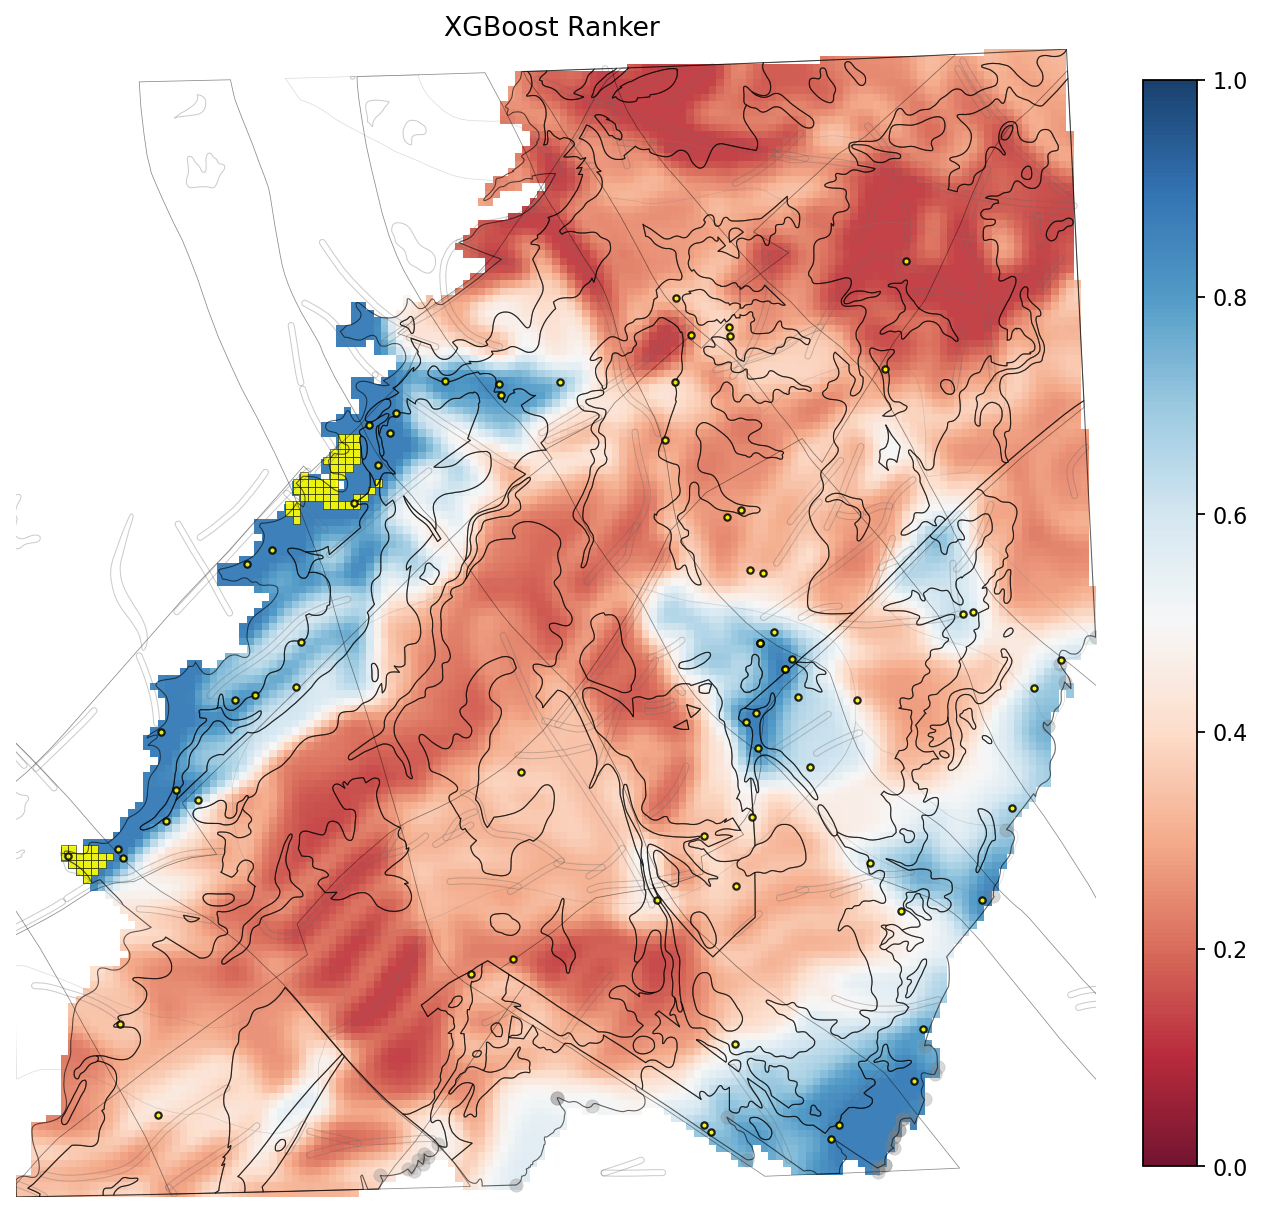

Сохранено PNG: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\xgboost_ranker\xgboost_ranker.png


In [66]:
def make_display_score(arr, valid_mask, q_low=3, q_high=97, contrast=0.72):
    disp = arr.astype(float).copy()
    lo = np.nanpercentile(disp[valid_mask], q_low)
    hi = np.nanpercentile(disp[valid_mask], q_high)
    disp = np.clip(disp, lo, hi)
    disp = (disp - lo) / (hi - lo + 1e-9)
    disp = 0.5 + contrast * (disp - 0.5)
    disp = np.clip(disp, 0, 1)
    return np.where(valid_mask, disp, np.nan)


def plot_one_map():
    valid_mask = np.isfinite(prospectivity_arr)
    display_score = make_display_score(prospectivity_arr, valid_mask)
    extent = (minx, maxx, miny, maxy)

    fig, ax = plt.subplots(1, 1, figsize=(8, 9), dpi=160)
    im = ax.imshow(display_score, origin="lower", extent=extent, cmap="RdBu", vmin=0, vmax=1, alpha=0.92)
    ax.set_title("XGBoost Ranker ", fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Контуры основных геологических объектов.
    for key, color, lw, alpha in [
        ("tect1", "black", 0.35, 0.45),
        ("tect2", "black", 0.35, 0.45),
        ("magm", "dimgray", 0.45, 0.35),
        ("paleo", "gray", 0.30, 0.30),
        ("struct", "gray", 0.30, 0.30),
    ]:
        try:
            gdf = layers[LAYER_MAP[key]]
            if len(gdf) > 0:
                gdf.boundary.plot(ax=ax, color=color, linewidth=lw, alpha=alpha)
        except Exception:
            pass

    # Top-zone оставляем жёлтой, как выделение локальных участков.
    top_gdf = grid[grid["top_zone"] == 1].copy()
    if len(top_gdf) > 0:
        top_gdf.plot(ax=ax, color="yellow", edgecolor="black", linewidth=0.25, alpha=0.90, label="Top zone")

    if SHOW_POINTS and len(evidence_points_plot) > 0:
        evidence_points_plot.plot(ax=ax, color="yellow", edgecolor="black", markersize=8, alpha=0.85, zorder=5)

    try:
        layers[LAYER_MAP["mask"]].boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.6)
    except Exception:
        pass

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()

    out_png = OUT_DIR / "xgboost_ranker.png"
    plt.savefig(out_png, bbox_inches="tight", dpi=220)
    plt.show()
    print("Сохранено PNG:", out_png)

plot_one_map()